In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
os.listdir("../data/raw")

['Online Retail.xlsx']

In [2]:
df =pd.read_excel("../data/raw/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [ ]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [19]:
df.describe()

,Quantity,UnitPrice,CustomerID,Revenue
count,539392.000000,539392.000000,406789.000000,539392.000000
mean,9.845904,4.673648,15287.795830,18.112749
std,215.412652,94.614722,1713.573064,379.091706
min,-80995.000000,0.001000,12346.000000,-168469.600000
25%,1.000000,1.250000,13954.000000,3.750000
50%,3.000000,2.080000,15152.000000,9.840000
75%,10.000000,4.130000,16791.000000,17.400000
max,80995.000000,38970.000000,18287.000000,168469.600000


In [20]:
df.shape

(539392, 9)

In [21]:
df.duplicated().sum()


np.int64(5263)

In [22]:
df.drop_duplicates()
df.shape

(539392, 9)

In [23]:
df["CustomerID"].isnull().mean() * 100

np.float64(24.58379063834836)

In [24]:
df = df.dropna(subset=["Description"])
df["Description"].isnull().sum()

np.int64(0)

In [11]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [12]:
(df["Quantity"] <= 0).sum()

np.int64(9288)

In [13]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [14]:
(df["Revenue"] < 0).sum()

np.int64(9288)

In [15]:
(df["Revenue"] == 0).sum()

np.int64(0)

In [16]:
((df["Quantity"] == 0) | (df["UnitPrice"] == 0)).sum()

np.int64(0)

In [17]:
(df["UnitPrice"] < 0).sum()

np.int64(0)

In [18]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [19]:
df = df[df["UnitPrice"] > 0]
(df["UnitPrice"] < 0).sum()

np.int64(0)

In [20]:
df["CustomerID"].isnull().sum()

np.int64(132603)

In [21]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

('2010-12-01 08:26:00', '2011-12-09 12:50:00')

In [22]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132603
Country             0
Revenue             0
dtype: int64

In [23]:
df.shape

(539392, 9)

In [25]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
Revenue        float64
dtype: object

In [26]:
df.to_csv("../data/cleaned/online_retail_cleaned.csv", index=False)

In [27]:
test_df = pd.read_csv("../data/cleaned/online_retail_cleaned.csv")

In [28]:
test_df.shape

(539392, 9)

## Data Cleaning Completed

The dataset was cleaned by removing duplicate records, handling missing descriptions, identifying cancellations and invalid values, and creating a Revenue column.

The cleaned dataset contains 539392 rows and 9 columns.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/online_retail_cleaned.csv")

In [8]:
df[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,539392.000000,539392.000000,539392.000000
mean,9.845904,4.673648,18.112749
std,215.412652,94.614722,379.091706
min,-80995.000000,0.001000,-168469.600000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.840000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [9]:
df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    530104
True       9288
Name: count, dtype: int64

In [10]:
df["Revenue"].sum()

np.float64(9769872.054)

In [11]:
df["StockCode"].nunique()

3938

In [12]:
df["CustomerID"].nunique()

4371

In [13]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    8209930.484
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

In [14]:
country_orders = df["Country"].value_counts()
country_orders.head(10)

Country
United Kingdom    492979
Germany             9493
France              8556
EIRE                8192
Spain               2532
Netherlands         2367
Belgium             2069
Switzerland         2001
Portugal            1519
Australia           1256
Name: count, dtype: int64

In [17]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [16]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_sales

InvoiceDate
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     704804.630
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64

In [21]:
daily_sales = df.groupby(df["InvoiceDate"].dt.to_period("D"))["Revenue"].sum()
daily_sales

InvoiceDate
2010-12-01    58635.56
2010-12-02    46207.28
2010-12-03    45620.46
2010-12-05    31383.95
2010-12-06    53860.18
                ...   
2011-12-05    57751.32
2011-12-06    54228.37
2011-12-07    75076.22
2011-12-08    81417.78
2011-12-09    32131.53
Freq: D, Name: Revenue, Length: 305, dtype: float64

In [23]:
weekday_sales = df.groupby(df["InvoiceDate"].dt.day_name())["Revenue"].sum()
weekday_sales

InvoiceDate
Friday       1562734.931
Monday       1588609.431
Sunday        805678.891
Thursday     2112519.000
Tuesday      1966182.791
Wednesday    1734147.010
Name: Revenue, dtype: float64

In [24]:
hourly_sales = df.groupby(df["InvoiceDate"].dt.hour)["Revenue"].sum()
hourly_sales

InvoiceDate
6        -497.350
7       31009.320
8      281840.860
9      766734.051
10    1329056.521
11    1147437.920
12    1362484.290
13    1177506.370
14    1117337.021
15    1189458.280
16     729140.820
17     435444.111
18     140574.480
19      46324.990
20      16020.370
Name: Revenue, dtype: float64

In [26]:
top_products_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products_qty

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47359
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35313
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26111
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

In [28]:
top_products_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

In [29]:
product_revenue = (
    df[~df["Description"].str.contains("POSTAGE|DOTCOM", case=False, na=False)]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue

Description
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
Name: Revenue, dtype: float64

In [30]:
bottom_products_revenue = (
    df[~df["Description"].str.contains("POSTAGE|DOTCOM", case=False, na=False)]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_products_revenue

Description
AMAZON FEE                        -221520.500
Manual                             -68671.640
CRUK Commission                     -7933.430
Bank Charges                        -7175.639
Discount                            -5696.220
SAMPLES                             -3049.390
WHITE CHERRY LIGHTS                   -54.000
CREAM SWEETHEART MAGAZINE RACK        -46.850
WOODEN BOX ADVENT CALENDAR            -45.700
ASSORTED TUTTI FRUTTI ROUND BOX       -39.600
Name: Revenue, dtype: float64

In [31]:
non_product = r"POSTAGE|DOTCOM|AMAZON FEE|MANUAL|CRUK COMMISSION|BANK CHARGES|DISCOUNT|SAMPLES"

bottom_products_revenue = (
    df[~df["Description"].str.contains(non_product, case=False, na=False)]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_products_revenue

Description
WHITE CHERRY LIGHTS               -54.00
CREAM SWEETHEART MAGAZINE RACK    -46.85
WOODEN BOX ADVENT CALENDAR        -45.70
ASSORTED TUTTI FRUTTI ROUND BOX   -39.60
PINK CHERRY LIGHTS                -27.00
BLUE PADDED SOFT MOBILE           -25.50
ANTIQUE LILY FAIRY LIGHTS         -14.85
CREAM SWEETHEART TRAYS            -12.75
TEA TIME CAKE STAND IN GIFT BOX   -10.75
CREAM SWEETHEART SHELF + HOOKS     -7.95
Name: Revenue, dtype: float64

In [33]:
customer_revenue = (
    df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

In [34]:
customer_orders = (
    df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

CustomerID
14911.0    248
12748.0    223
17841.0    169
14606.0    128
13089.0    118
15311.0    118
12971.0     89
14527.0     86
13408.0     81
16029.0     76
Name: InvoiceNo, dtype: int64

In [35]:
total_orders = df["InvoiceNo"].nunique()
cancelled_orders = df[df["InvoiceNo"].astype(str).str.startswith("C")]["InvoiceNo"].nunique()

cancellation_rate = (cancelled_orders / total_orders) * 100

cancellation_rate

16.12035636241385

In [36]:
cancelled_revenue = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]["Revenue"].sum()

cancelled_revenue

np.float64(-896812.49)

In [37]:
cancellation_impact = (abs(cancelled_revenue) / df["Revenue"].sum()) * 100

cancellation_impact

np.float64(9.179367805874442)

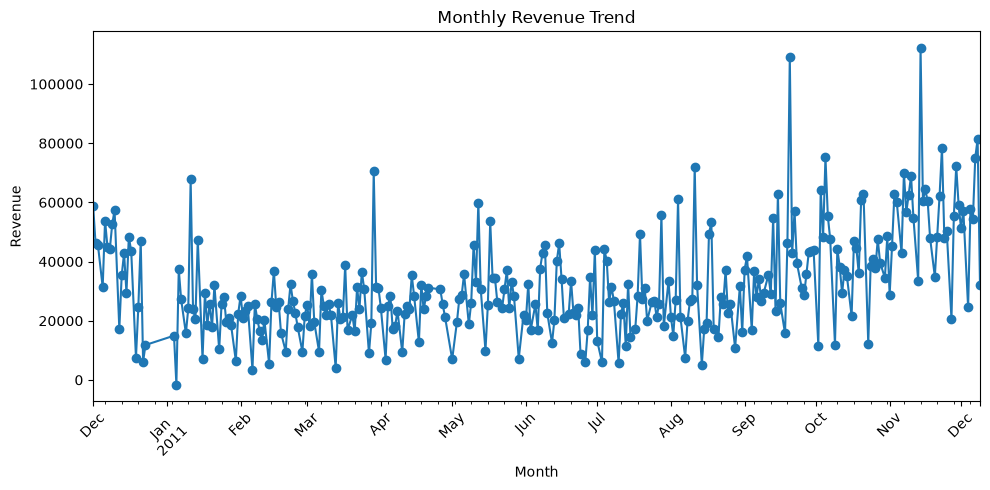

In [38]:
monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

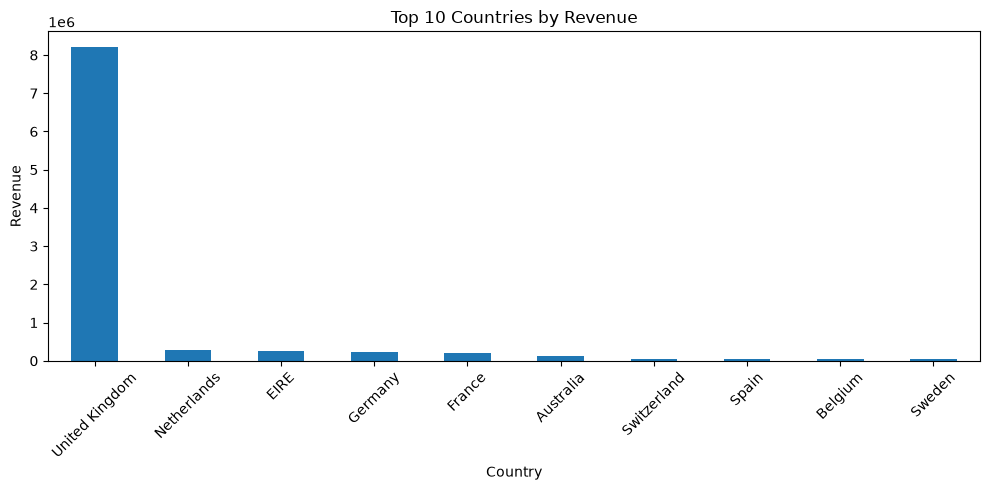

In [39]:
top_countries = country_sales.head(10)

top_countries.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

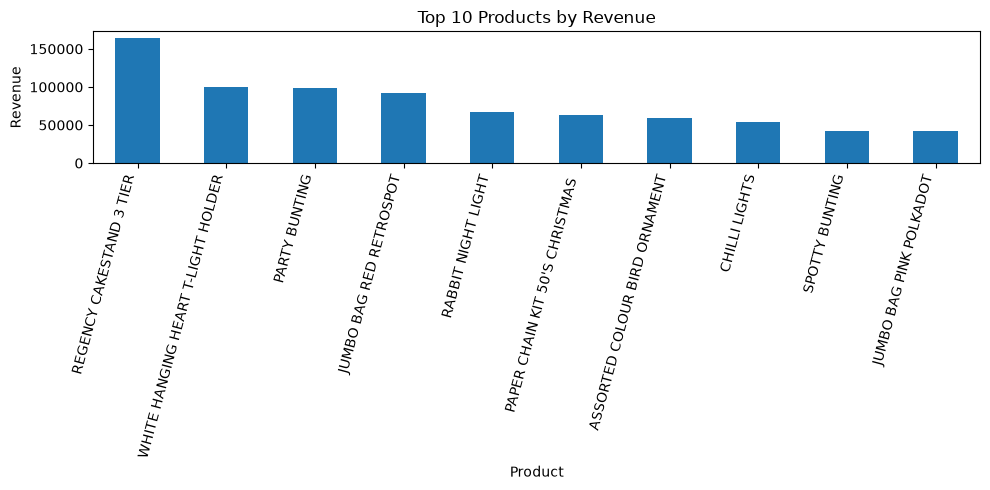

In [40]:
product_revenue.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

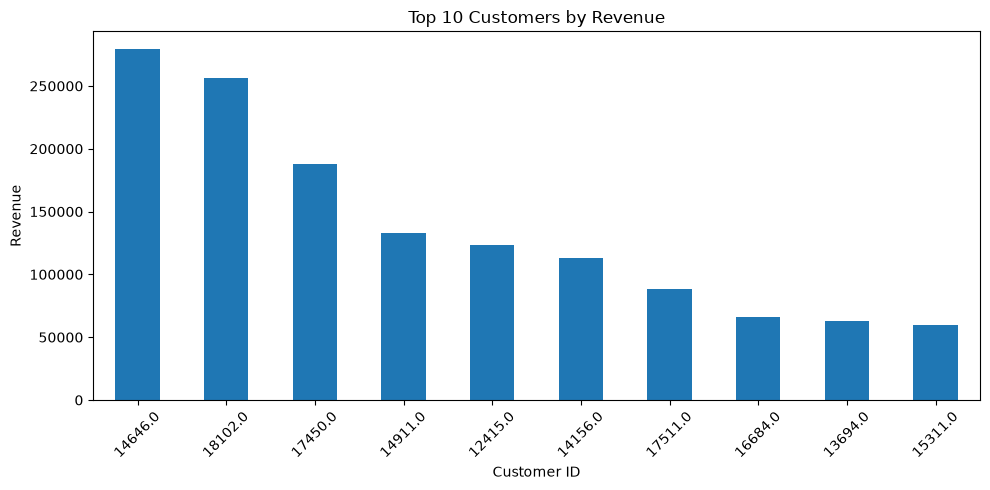

In [41]:
top_customers = customer_revenue.head(10)

top_customers.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

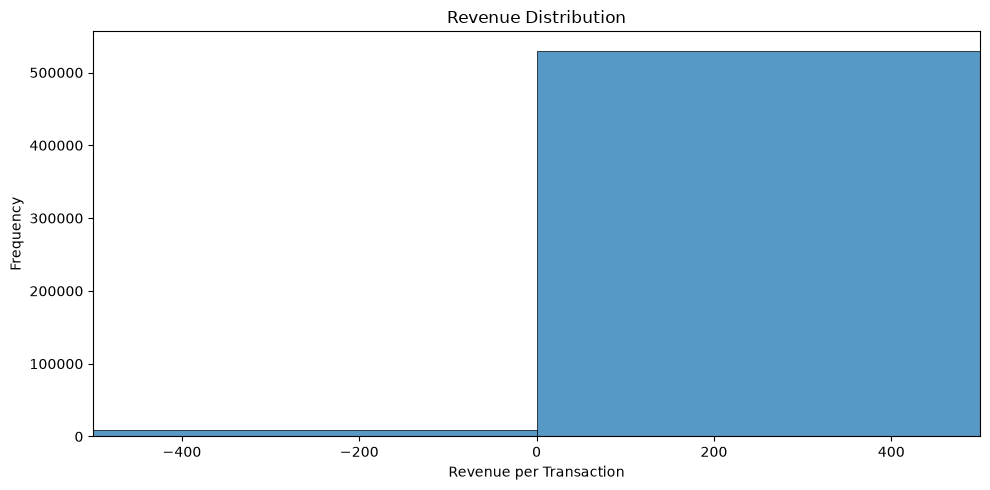

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Revenue"], bins=100)

plt.title("Revenue Distribution")
plt.xlabel("Revenue per Transaction")
plt.ylabel("Frequency")
plt.xlim(-500, 500)
plt.tight_layout()
plt.show()

## Key EDA Findings

- The United Kingdom generated the highest revenue, contributing the majority of total sales.
- November 2011 recorded the highest monthly revenue, while December is only a partial month.
- Thursday generated the highest total revenue among weekdays.
- Revenue was concentrated during daytime business hours, with 12 PM recording the highest hourly revenue.
- REGENCY CAKESTAND 3 TIER was the highest-revenue physical product.
- Customer 14646 generated the highest total revenue, while customer 14911 placed the most orders.
- Cancellation invoices represented 16.12% of unique invoices.
- Cancellation invoices had a negative revenue impact of approximately £896.8K.

## Data Visualization

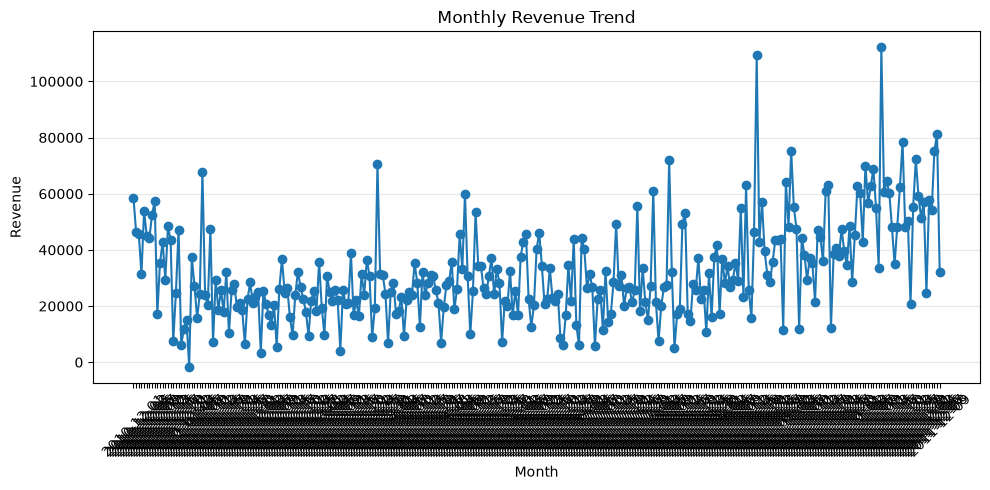

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

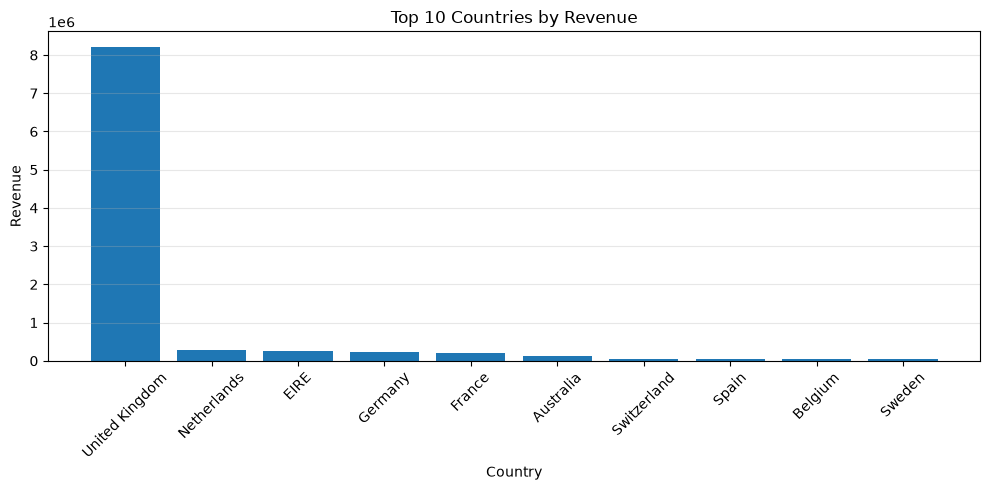

In [44]:
plt.figure(figsize=(10, 5))

plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

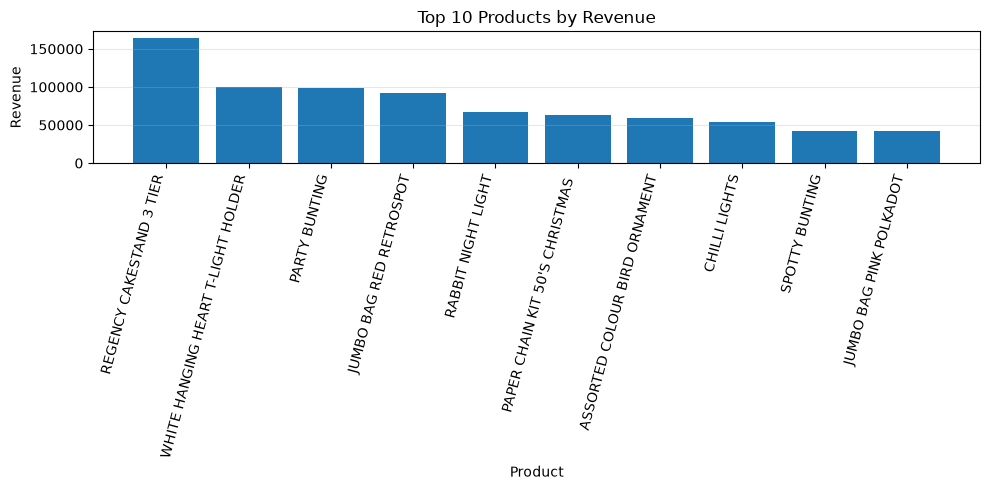

In [45]:
plt.figure(figsize=(10, 5))

plt.bar(product_revenue.index, product_revenue.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

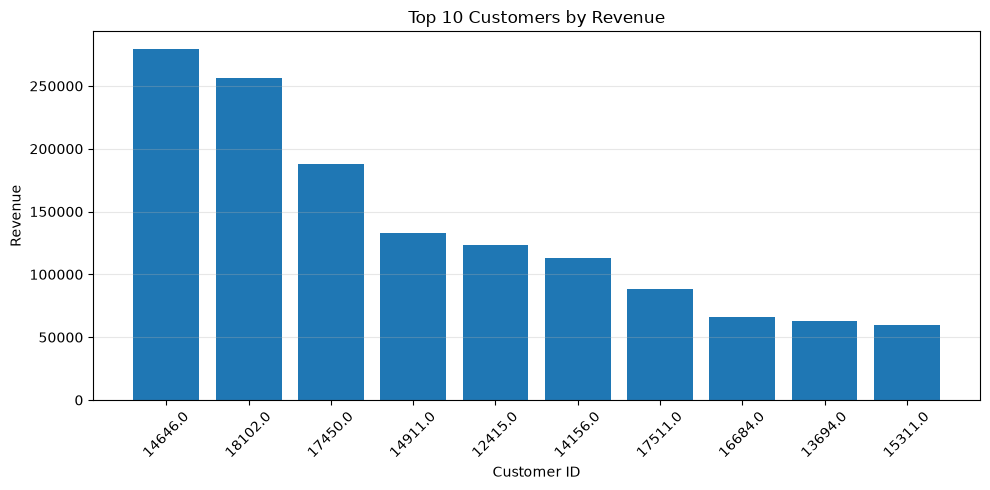

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(top_customers.index.astype(str), top_customers.values)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

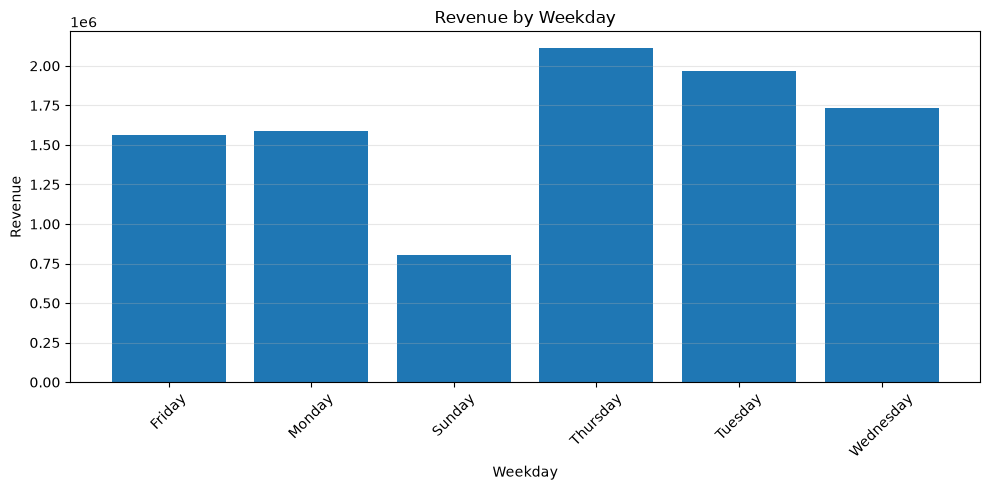

In [47]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_sales.index, weekday_sales.values)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

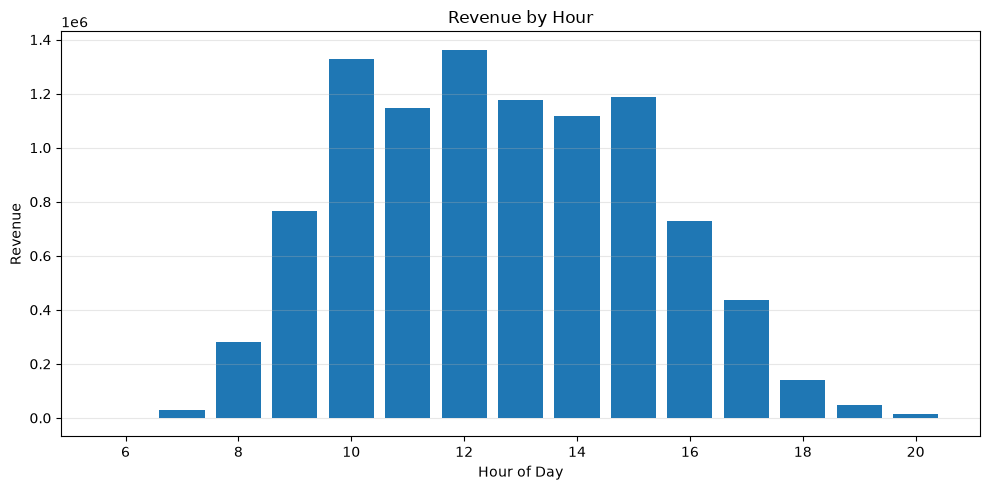

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(hourly_sales.index, hourly_sales.values)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

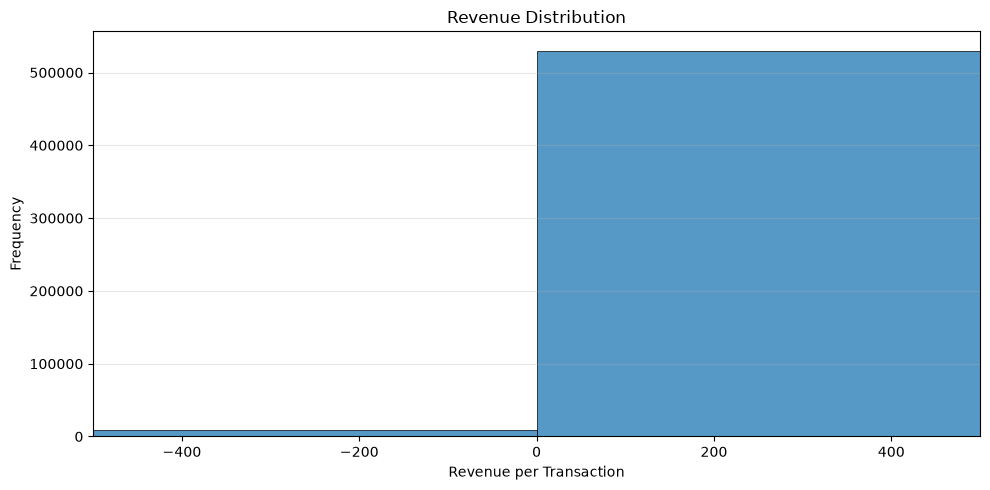

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Revenue"], bins=100)

plt.title("Revenue Distribution")
plt.xlabel("Revenue per Transaction")
plt.ylabel("Frequency")
plt.xlim(-500, 500)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization Summary

The visualizations highlight monthly sales trends, geographic revenue distribution, top-performing products and customers, and revenue patterns across weekdays and hours.

## Business Insights

### 1. Strong UK Market Concentration

The United Kingdom generated approximately £8.21M in recorded revenue, making it the dominant market in the dataset. This indicates a strong dependence on the UK market and highlights the potential importance of international markets for future growth.

### 2. Revenue Peaks Toward the End of the Year

Revenue increased substantially during the later months of 2011, reaching approximately £1.46M in November. This suggests stronger sales activity toward the year-end period. December should be interpreted cautiously because the dataset ends on December 9, 2011.

### 3. Cancellations Have a Significant Revenue Impact

Cancellation invoices represented 16.12% of unique invoices. These cancellation transactions had a negative revenue impact of approximately £896.8K, equivalent to about 9.18% of total recorded revenue. This highlights the importance of monitoring returns and cancellations when evaluating sales performance.

### 4. Product Performance Is Concentrated

REGENCY CAKESTAND 3 TIER generated approximately £164.8K in revenue, making it the highest-revenue physical product in the dataset. Other strong performers include WHITE HANGING HEART T-LIGHT HOLDER, PARTY BUNTING, and JUMBO BAG RED RETROSPOT.

### 5. Customer Value and Order Frequency Differ

Customer 14646 generated the highest revenue at approximately £279.5K, while customer 14911 placed the most orders with 248 invoices. This shows that the highest-value customer is not necessarily the customer with the highest order frequency.

### 6. Sales Are Concentrated During Business Hours

Revenue is concentrated during daytime hours, with 12 PM generating the highest recorded hourly revenue at approximately £1.36M. This pattern can help identify the periods of highest transaction activity for operational planning.

## Conclusion

This analysis explored transaction-level e-commerce data to identify sales trends, geographic performance, product performance, customer behavior, and cancellation patterns. The findings show strong UK market concentration, higher revenue toward the end of the year, significant cancellation impact, and differences between customer revenue and order frequency.

These insights demonstrate how Python-based data analysis can transform raw transaction data into useful business information for decision-making.